In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

In [4]:
data = pd.read_csv("heart.csv")
data.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


## EDA & Data Cleaning

In [5]:
data.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='str')

In [6]:
data.shape

(918, 12)

In [7]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


In [8]:
data.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [9]:
data.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [10]:
data.duplicated().sum()

np.int64(0)

In [13]:
data['HeartDisease'].value_counts()

HeartDisease
1    508
0    410
Name: count, dtype: int64

<Axes: xlabel='HeartDisease'>

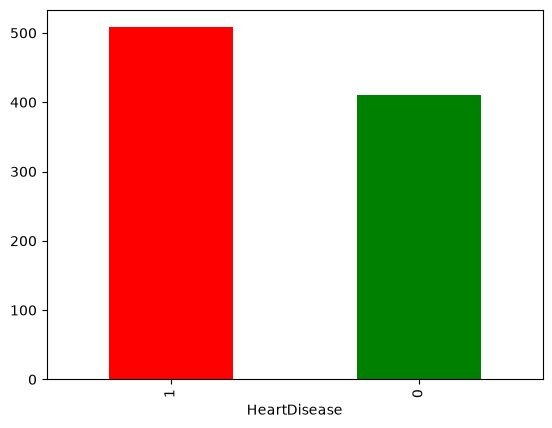

In [16]:
data['HeartDisease'].value_counts().plot(kind='bar', color=['red', 'green'])

In [18]:
data.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


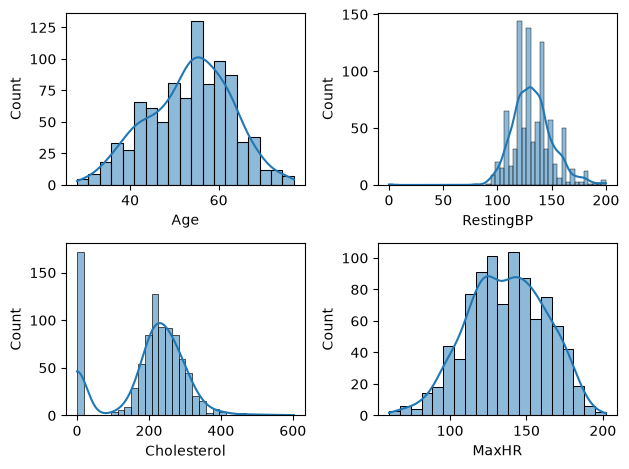

In [20]:
# Create a function to see the distribution of categorical features in subplots
def plots(var, num):
    plt.subplot(2,2,num)
    sns.histplot(data[var], kde = True)

plots("Age", 1)
plots("RestingBP", 2)
plots("Cholesterol", 3)
plots("MaxHR", 4)

plt.tight_layout()

In [23]:
# Cholesterol value counts
data['Cholesterol'].value_counts()

Cholesterol
0      172
254     11
223     10
220     10
211      9
      ... 
353      1
278      1
157      1
176      1
131      1
Name: count, Length: 222, dtype: int64

In [25]:
# In Cholesterol subplot there is some data which is not possible to have 0 values. So we will replace those 0 values with the mean of the respective columns.
ch_mean = data.loc[data['Cholesterol'] != 0, 'Cholesterol'].mean()
ch_mean

np.float64(244.6353887399464)

In [30]:
# Resplace 0 Cholesterol values with mean
data['Cholesterol'] = data['Cholesterol'].replace(0, ch_mean)
data['Cholesterol'] = data['Cholesterol'].round(2)

In [31]:
# RestingBP value counts
data['RestingBP'].value_counts()

RestingBP
120    132
130    118
140    107
110     58
150     55
      ... 
174      1
117      1
192      1
129      1
164      1
Name: count, Length: 67, dtype: int64

In [27]:
# In RestingBP subplot there is some data which is not possible to have 0 values. So we will replace those 0 values with the mean of the respective columns.
restBP_mean = data.loc[data['RestingBP'] !=0, 'RestingBP'].mean()
restBP_mean

np.float64(132.54089422028352)

In [33]:
# Replace 0 RestingBP values with mean
data['RestingBP'] = data['RestingBP'].replace(0, restBP_mean)
data['RestingBP'] = data['RestingBP'].round(2)

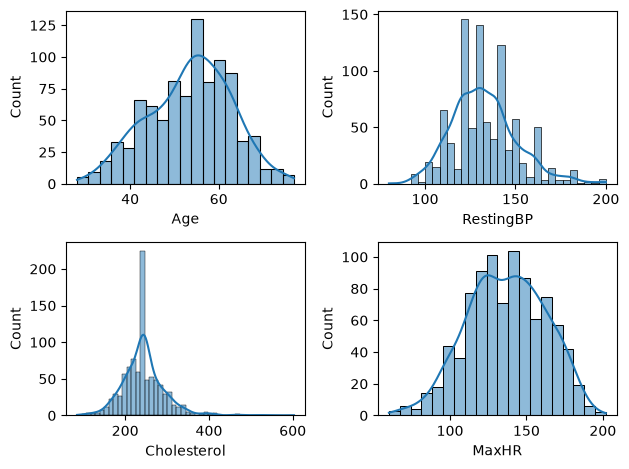

In [34]:
# Create a function to see the distribution of numerical features in subplots after replacing 0 values with mean
def plots(var, num):
    plt.subplot(2,2,num)
    sns.histplot(data[var], kde = True)

plots("Age", 1)
plots("RestingBP", 2)
plots("Cholesterol", 3)
plots("MaxHR", 4)

plt.tight_layout()

<Axes: xlabel='Sex', ylabel='count'>

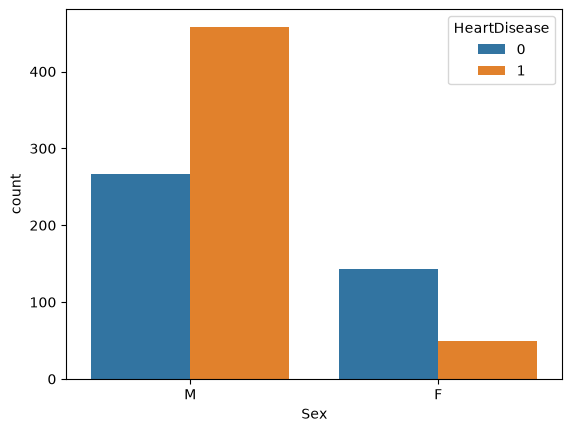

In [37]:
# Create countplots for gender and heart disease
sns.countplot(x = 'Sex', data = data, hue = 'HeartDisease')

<Axes: xlabel='ChestPainType', ylabel='count'>

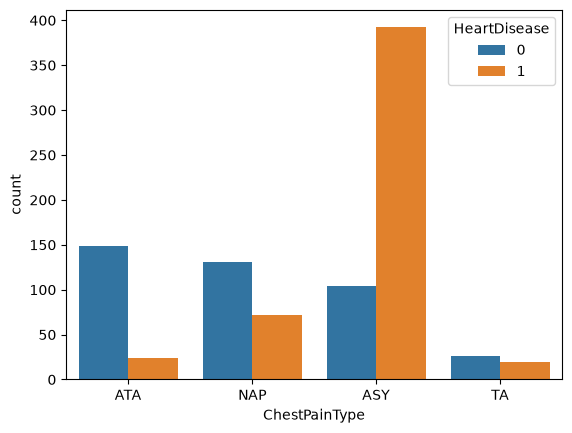

In [47]:
# Create countplots for ChestpainType and heart disease
sns.countplot(x = data['ChestPainType'], data = data, hue = data['HeartDisease'])

<Axes: xlabel='RestingECG', ylabel='count'>

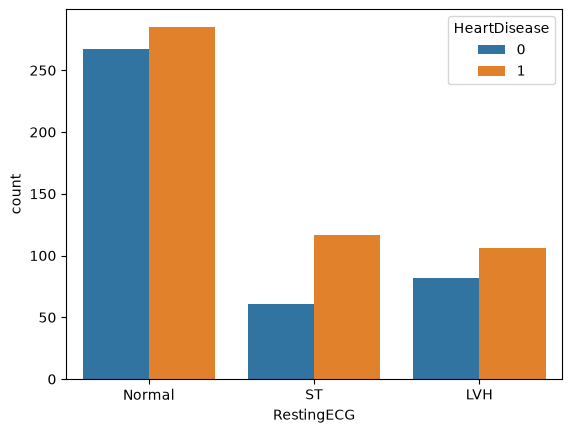

In [48]:
# Create countplot for RestingECG and heart disease
sns.countplot(x = data['RestingECG'], data = data, hue = data['HeartDisease'])

<Axes: xlabel='FastingBS', ylabel='count'>

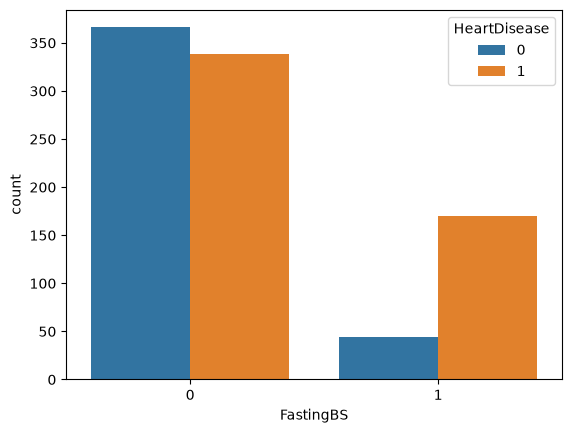

In [50]:
# Create countplot for FastingBS and heart disease
sns.countplot(x = data['FastingBS'], data = data, hue = data['HeartDisease'])

<Axes: xlabel='HeartDisease', ylabel='Cholesterol'>

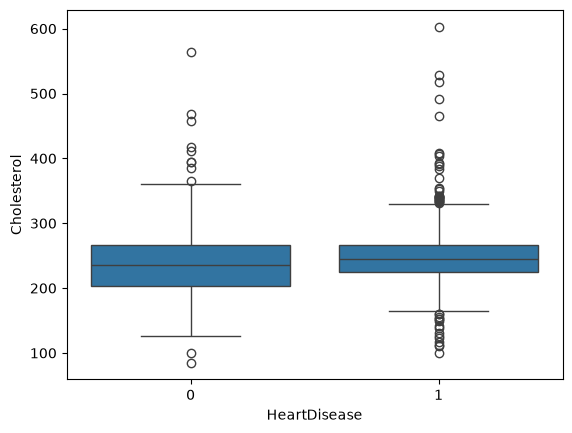

In [53]:
# Create boxplot for Cholesterol and heart disease
sns.boxplot(x = data['HeartDisease'], y = data['Cholesterol'], data = data)

<Axes: xlabel='HeartDisease', ylabel='Age'>

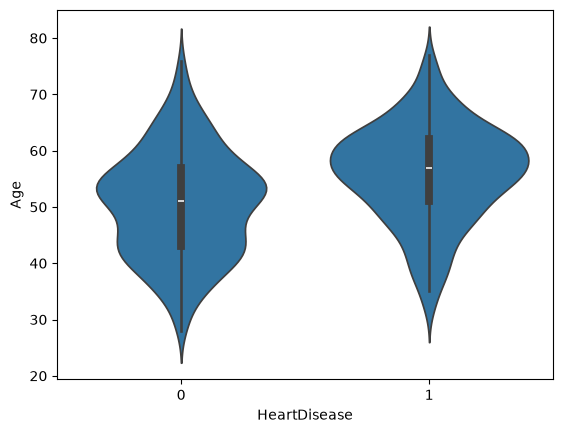

In [54]:
# Create violinplot for Age and heart disease
sns.violinplot(x = data['HeartDisease'], y = data['Age'], data = data)

<Axes: xlabel='HeartDisease', ylabel='MaxHR'>

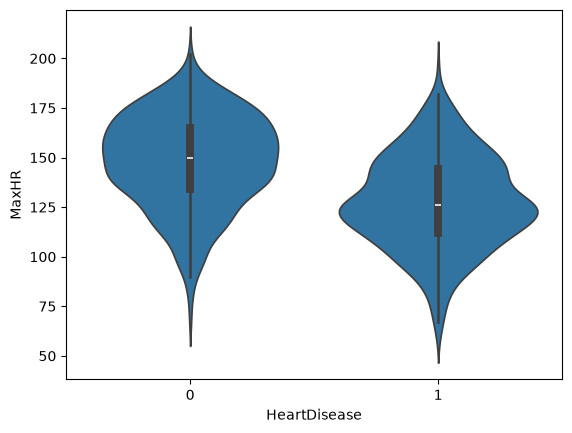

In [55]:
# Create Violinplot for MaxHR and heart disease
sns.violinplot(x = data['HeartDisease'], y = data['MaxHR'], data = data)

<Axes: >

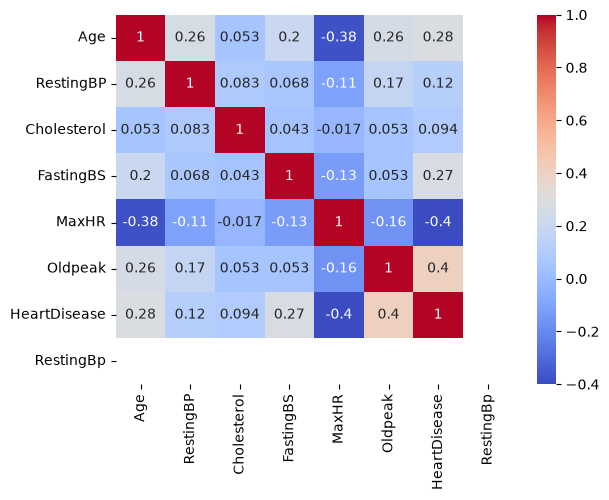

In [57]:
# Create heatmap for correlation between features
sns.heatmap(data.corr(numeric_only=True), annot = True, cmap = "coolwarm")


## Data Preprocessing

In [ ]:
# Clean duplicates column op[p[and90-]]
if "RestingBp" in data.columns:
    data = data.drop(columns=["RestingBp"])

In [102]:
# Encode categorical features using one-hot encoding
data_encoded = pd.get_dummies(data, drop_first=False)

In [103]:
data_encoded.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,Sex_M,ChestPainType_ASY,...,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,140.0,289.0,0,172,0.0,0,False,True,False,...,False,False,False,True,False,True,False,False,False,True
1,49,160.0,180.0,0,156,1.0,1,True,False,False,...,True,False,False,True,False,True,False,False,True,False
2,37,130.0,283.0,0,98,0.0,0,False,True,False,...,False,False,False,False,True,True,False,False,False,True
3,48,138.0,214.0,0,108,1.5,1,True,False,True,...,False,False,False,True,False,False,True,False,True,False
4,54,150.0,195.0,0,122,0.0,0,False,True,False,...,True,False,False,True,False,True,False,False,False,True


In [105]:
data_encoded.columns

Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease', 'Sex_F', 'Sex_M', 'ChestPainType_ASY',
       'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA',
       'RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST',
       'ExerciseAngina_N', 'ExerciseAngina_Y', 'ST_Slope_Down',
       'ST_Slope_Flat', 'ST_Slope_Up'],
      dtype='str')

In [106]:
# Convert encoded data into Integer type
data_encoded = (
    data_encoded
    .replace([np.inf, -np.inf], np.nan)  # handle inf values
    .fillna(0)                           # handle NaN values
    .round(0)                            # avoid unintended truncation
    .astype(int)
)

# data_encoded = data_encoded.astype(int)

In [108]:
data_encoded

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,Sex_M,ChestPainType_ASY,...,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0,0,0,1,0,...,0,0,0,1,0,1,0,0,0,1
1,49,160,180,0,156,1,1,1,0,0,...,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0,0,0,1,0,...,0,0,0,0,1,1,0,0,0,1
3,48,138,214,0,108,2,1,1,0,1,...,0,0,0,1,0,0,1,0,1,0
4,54,150,195,0,122,0,0,0,1,0,...,1,0,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110,264,0,132,1,1,0,1,0,...,0,1,0,1,0,1,0,0,1,0
914,68,144,193,1,141,3,1,0,1,1,...,0,0,0,1,0,1,0,0,1,0
915,57,130,131,0,115,1,1,0,1,1,...,0,0,0,1,0,0,1,0,1,0
916,57,130,236,0,174,0,1,1,0,0,...,0,0,1,0,0,1,0,0,1,0


In [109]:
# Standard Scalling the data
from sklearn.preprocessing import StandardScaler

numeric_cols = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]
scaler = StandardScaler()
data_encoded[numeric_cols] = scaler.fit_transform(data_encoded[numeric_cols])

In [111]:
data_encoded

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,Sex_M,ChestPainType_ASY,...,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0.414825,0.831244,0,1.382928,-0.803849,0,0,1,0,...,0,0,0,1,0,1,0,0,0,1
1,-0.478484,1.527163,-1.214200,0,0.754157,0.096070,1,1,0,0,...,1,0,0,1,0,1,0,0,1,0
2,-1.751359,-0.141345,0.718651,0,-1.525138,-0.803849,0,0,1,0,...,0,0,0,0,1,1,0,0,0,1
3,-0.584556,0.303591,-0.576172,0,-1.132156,0.995988,1,1,0,1,...,0,0,0,1,0,0,1,0,1,0
4,0.051881,0.970994,-0.932717,0,-0.581981,-0.803849,0,0,1,0,...,1,0,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,-0.902775,-1.253683,0.362105,0,-0.188999,0.096070,1,0,1,0,...,0,1,0,1,0,1,0,0,1,0
914,1.536902,0.637292,-0.970248,1,0.164684,1.895907,1,0,1,1,...,0,0,0,1,0,1,0,0,1,0
915,0.370100,-0.141345,-2.133711,0,-0.857069,0.096070,1,0,1,1,...,0,0,0,1,0,0,1,0,1,0
916,0.370100,-0.141345,-0.163330,0,1.461525,-0.803849,1,1,0,0,...,0,0,1,0,0,1,0,0,1,0
